## Experimentation

## Imports

In [2]:
import sys
sys.path.append("/mnt/D/University/Thesis/src")

In [10]:
from BoardDetection.BoardDetector_YOLO.BoardDetector_YOLO import BoardDetector_YOLO

import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
import cv2

import torch
from torchvision import transforms

from sklearn.cluster import DBSCAN

import os
from Dataset.data import DataPath

## Constants

In [11]:
bd = BoardDetector_YOLO()

def detect_board_img(img):
    bd.set_img(img)
    mask, conf = bd.predict()
    return mask, conf

## Loading Image

In [14]:
transform = transforms.Compose([
    transforms.ToTensor()
])
# img_pill = Image.open(os.path.join(DataPath, "data_manual/1741715439429.jpg")).convert("RGB")
img_pill = Image.open(os.path.join(DataPath, "data_manual/1741715439533.jpg")).convert("RGB").resize((640,640))
# img_pill = Image.open("../data/image_0.jpg").convert("RGB").resize((640,640))
img_gray = transform(img_pill.convert("L")).squeeze()
img: torch.Tensor = transform(img_pill)
img.shape, img.dtype, img.max(), img.min(), img_gray.shape, img_gray.dtype, img_gray.max(), img_gray.min()

(torch.Size([3, 640, 640]),
 torch.float32,
 tensor(1.),
 tensor(0.0235),
 torch.Size([640, 640]),
 torch.float32,
 tensor(1.),
 tensor(0.0510))

## YOLO Segmentation

In [15]:
img_tmp = (img.permute(1,2,0) * 255).to(torch.uint8)
mask, conf = detect_board_img(img_tmp)
conf

/home/mostafaelfaggal/.local/lib/python3.13/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


0.9476468563079834

((640, 640), torch.Size([640, 640]))

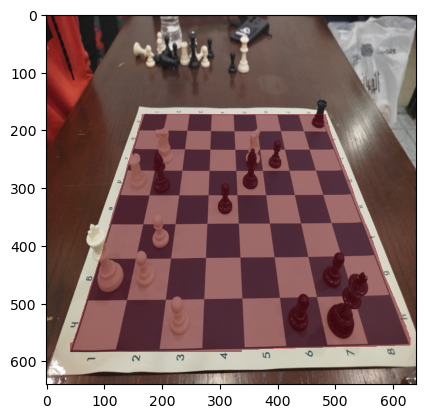

In [16]:
mask_tmp = transform(Image.fromarray(mask).resize((img.shape[2], img.shape[1]))).squeeze()
mask_tmp[mask_tmp < .1] = 0
mask_tmp[mask_tmp > 1] = 1
plt.imshow(img.permute(1,2,0));
plt.imshow(mask_tmp, alpha=mask_tmp*.5, cmap="Reds");
mask.shape, mask_tmp.shape

## Saddle Point Detection

In [156]:
def getSaddle(gray_img):
    img = gray_img.astype(np.float64)
    gx = cv2.Sobel(img,cv2.CV_64F,1,0)
    gy = cv2.Sobel(img,cv2.CV_64F,0,1)
    gxx = cv2.Sobel(gx,cv2.CV_64F,1,0)
    gyy = cv2.Sobel(gy,cv2.CV_64F,0,1)
    gxy = cv2.Sobel(gx,cv2.CV_64F,0,1)

    S = gxx*gyy - gxy**2
    return S

def nonmax_suppression(S, thresh=0.1, window_size=5):
    # Take absolute value for saddle strength
    S_abs = np.abs(S)
    
    # Normalize to [0,1]
    S_norm = S_abs / S_abs.max()

    # Threshold
    mask = S_norm > thresh

    # Dilation to find local maxima
    dilated = cv2.dilate(S_norm, np.ones((window_size, window_size), np.uint8))
    local_max = (S_norm == dilated)

    # Keep only local maxima above threshold
    final_mask = mask & local_max

    # Get coordinates
    pts = np.column_stack(np.nonzero(final_mask))[:,[1,0]]
    return pts, final_mask

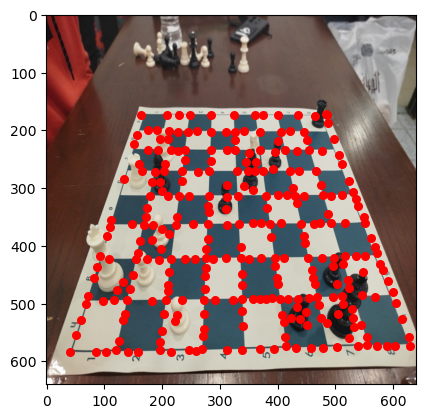

In [158]:
S = getSaddle((img_gray * mask_tmp).numpy())
S = -S
S[S<0] = 0
pts, S_sup = nonmax_suppression(S, .01, 20)

plt.imshow(img.permute(1,2,0));
plt.scatter(pts[:,0], pts[:,1], c='r', s=30);

## Estimating Board

In [160]:
def make_chessboard_model(cols, rows, square_size=1.0):
    # cols = number of inner corners horizontally
    # rows = number of inner corners vertically
    model_pts = []
    for y in range(rows):
        for x in range(cols):
            model_pts.append((x * square_size, y * square_size))
    return np.array(model_pts, dtype=np.float32)

model_pts = make_chessboard_model(7, 7)

def spatially_filter_points(pts, strengths, min_dist=10):
    """
    pts: Nx2 array (x, y)
    strengths: list/array of N scores (higher = stronger)
    min_dist: minimum distance in pixels between kept points
    """
    # Sort by strength descending
    order = np.argsort(strengths)[::-1]
    pts_sorted = pts[order]
    strengths_sorted = strengths[order]

    kept = []
    for p in pts_sorted:
        if all(np.linalg.norm(p - np.array(k)) >= min_dist for k in kept):
            kept.append(p)
    return np.array(kept, dtype=np.float32)

def align_points_with_pca_snapped(pts):
    mean = np.mean(pts, axis=0)
    centered = pts - mean

    cov = np.cov(centered.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, order]

    # Angle of first eigenvector
    angle = np.arctan2(eigvecs[1, 0], eigvecs[0, 0])
    
    # Snap to nearest 90°
    snap_angle = np.round(angle / (np.pi/2)) * (np.pi/2)
    
    # Final rotation angle
    rot_angle = angle - snap_angle

    # Rotation matrix
    R = np.array([
        [np.cos(-rot_angle), -np.sin(-rot_angle)],
        [np.sin(-rot_angle),  np.cos(-rot_angle)]
    ])

    rotated = centered @ R.T
    return rotated, R, mean

def plot_pca_axes(img_pts, eigvecs, mean, scale=100):
    """
    img_pts: Nx2 array of (x, y) points in image coordinates
    eigvecs: 2x2 array, columns are eigenvectors from PCA
    mean: 2-element array, the center of the points
    scale: length of drawn axes in pixels
    """
    plt.figure(figsize=(6,6))
    plt.scatter(img_pts[:,0], img_pts[:,1], c='red', s=40, label='Saddle points')
    plt.scatter(mean[0], mean[1], c='blue', s=80, marker='x', label='Center')

    # Draw first principal axis
    plt.arrow(mean[0], mean[1],
              eigvecs[0,0]*scale, eigvecs[1,0]*scale,
              color='green', width=2, label='1st PCA axis')

    # Draw second principal axis
    plt.arrow(mean[0], mean[1],
              eigvecs[0,1]*scale, eigvecs[1,1]*scale,
              color='orange', width=2, label='2nd PCA axis')

    plt.gca().invert_yaxis()  # to match image coordinates
    plt.gca().set_aspect('equal', adjustable='box')
    plt.legend()
    plt.title("PCA Axes on Detected Saddle Points")
    plt.show()


def cluster_points_dbscan(pts, eps=10, min_samples=1):
    """
    pts: Nx2 array of (x, y)
    eps: max distance for points to be in same cluster (pixels)
    min_samples: min points to form a cluster
    """
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(pts)
    labels = clustering.labels_
    return labels  # same index as pts

def filter_points_by_clustering(pts, strengths, eps=10, min_samples=1):
    """
    Filter points by clustering nearby detections and keeping the strongest in each cluster.
    
    Parameters
    ----------
    pts : ndarray of shape (N, 2)
        (x, y) coordinates of detected points in pixels.
    strengths : array-like of shape (N,)
        Scores/strengths for each point (higher = stronger).
    eps : float
        Maximum distance in pixels for points to be in the same cluster.
    min_samples : int
        Minimum number of points to form a cluster (DBSCAN parameter).
    
    Returns
    -------
    filtered_pts : ndarray of shape (M, 2)
        Filtered points, one per cluster.
    """
    # Run DBSCAN clustering
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(pts)
    labels = clustering.labels_

    filtered_pts = []
    for lbl in np.unique(labels):
        if lbl == -1:  # noise points — keep them as their own
            noise_pts = pts[labels == lbl]
            noise_strengths = np.array(strengths)[labels == lbl]
            # Keep the strongest noise point (usually just 1 point)
            best_idx = np.argmax(noise_strengths)
            filtered_pts.append(noise_pts[best_idx])
        else:
            cluster_pts = pts[labels == lbl]
            cluster_strengths = np.array(strengths)[labels == lbl]
            best_idx = np.argmax(cluster_strengths)
            filtered_pts.append(cluster_pts[best_idx])

    return np.array(filtered_pts, dtype=np.float32)

array([     1582.4,      1429.7])

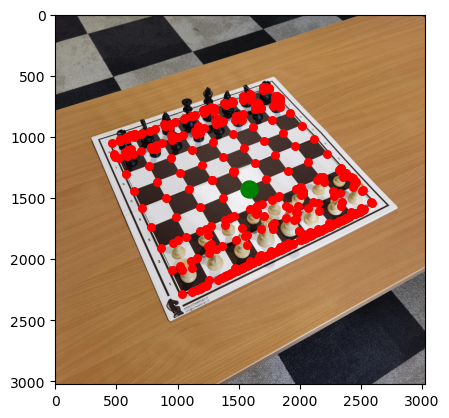

In [173]:
plt.imshow(img.permute(1,2,0));
plt.scatter(pts[:,0], pts[:,1], c='r', s=30);

mean = pts.mean(axis=0)
plt.scatter(mean[0], mean[1], c='g', s=150);
mean

In [162]:
# Get strengths from your saddle score map S
strengths = np.abs([S[y, x] for y, x in pts])

# Filter out clustered points
filtered_pts = filter_points_by_clustering(pts, strengths, eps=12)

# Now you can safely run PCA
new_pts, eigvecs, mean = align_points_with_pca_snapped(filtered_pts)

array([     1441.3,        1338], dtype=float32)

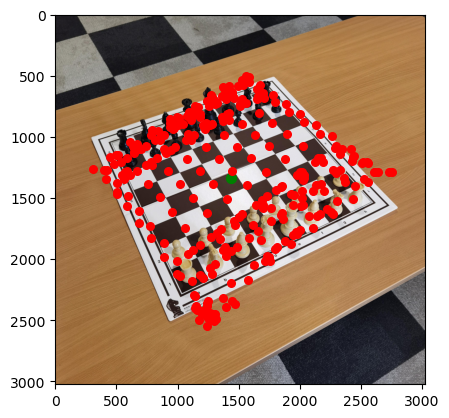

In [ ]:
# strengths = np.abs([S[x,y] for x, y in pts])
# kept = spatially_filter_points(pts, strengths)
# new_pts, _, mean = align_points_with_pca_snapped(kept)

# rotated_pts, eigvecs, mean = align_points_with_pca_snapped(kept)
# plot_pca_axes(pts, eigvecs, mean, scale=1500)

new_pts = new_pts + mean

plt.imshow(img.permute(1,2,0));
plt.scatter(mean[0], mean[1], c='g', s=50)
# plt.scatter(kept[:,0], kept[:,1], c='r', s=30);
plt.scatter(new_pts[:,0], new_pts[:,1], c='r', s=30);
mean

In [ ]:
cv2.findHomography(src, dst, cv2.RANSAC)

In [159]:
def fit_and_draw_filled_square(img, pts, color=(0, 255, 0), alpha=0.4):
    """
    Fits a square/rectangle to pts and draws it filled on img.
    img: BGR image
    pts: Nx2 (x, y) array
    color: fill color in BGR
    alpha: transparency for the fill
    """
    # Convex hull
    hull = cv2.convexHull(pts.astype(np.float32))
    # plt.scatter(hull[:,0,0], hull[:,0,1], c='b', s=50, zorder=3);

    epsilon = 0.02 * cv2.arcLength(hull, True)  # 2% of perimeter
    quad = cv2.approxPolyDP(hull, epsilon, True)

    quad = quad.reshape(-1, 2)  # (4,2) if it found a quadrilateral
    print(quad)

    # # Fit min area rectangle
    # rect = cv2.minAreaRect(hull)
    # box = cv2.boxPoints(rect)  # 4 corners
    # box = np.int32(box)

    # # Create overlay for transparency
    # overlay = img.copy()
    # cv2.fillPoly(overlay, [box], color)

    # # Blend overlay with original
    # cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0, img)

    # # Optionally draw rectangle outline
    # cv2.polylines(img, [box], isClosed=True, color=(0, 0, 255), thickness=2)

    # return img, box
    return quad

def best_fit_quad(pts):
    # Step 1: convex hull
    hull = cv2.convexHull(pts)

    # Step 2: try different epsilons to get 4 vertices
    best_quad = None
    best_score = -1

    for eps_factor in np.linspace(0.001, 0.05, 50):
        approx = cv2.approxPolyDP(hull, eps_factor * cv2.arcLength(hull, True), True)
        if len(approx) == 4:
            quad = approx.reshape(4, 2)

            # Step 3: create mask and count coverage
            mask = np.zeros((img.shape[2], img.shape[1]), dtype=np.uint8)  # adjust size if needed
            scaled_quad = np.int32(quad)  # Ensure int
            cv2.fillPoly(mask, [scaled_quad], 255)

            # Scale/shift points into mask coordinates
            min_xy = pts.min(axis=0)
            shifted_pts = (pts - min_xy).astype(int)
            shifted_quad = (quad - min_xy).astype(int)
            mask = np.zeros((shifted_pts[:,1].max()+5, shifted_pts[:,0].max()+5), dtype=np.uint8)
            cv2.fillPoly(mask, [shifted_quad], 255)

            coverage = np.sum(mask[shifted_pts[:,1], shifted_pts[:,0]] > 0)

            # Score = coverage + area importance
            area = cv2.contourArea(shifted_quad)
            score = coverage + 0.001 * area

            if score > best_score:
                best_score = score
                best_quad = quad

    return best_quad

array([[629, 574],
       [ 40, 584],
       [164, 173],
       [484, 172]], dtype=int32)

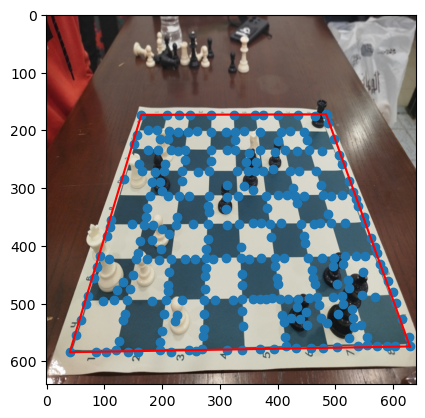

In [160]:
quad = best_fit_quad(pts)
plt.imshow(img.permute(1,2,0))
plt.scatter(*zip(*pts))
plt.plot(*zip(*(list(quad) + [quad[0]])), 'r-');
quad

## Test

In [2]:
import sys
sys.path.append("/mnt/D/University/Thesis/src")

In [12]:
from BoardDetection.BoardDetector_YOLO_Saddle import Bounded_Saddle_Yolo

import os

from torchvision import transforms
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image

import importlib
importlib.reload(Bounded_Saddle_Yolo);

from Dataset.data import DataPath
from Dataset.DataSetLoaders.ChessDataset import ChessDataset

In [13]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [ ]:
# img_path = os.path.join(DataPath, "data2/image4.jpg")
# img_path = os.path.join(DataPath, "data_manual/1741715439516.jpg")
# img_path = os.path.join(DataPath, "data_old/44.jpeg")
# img_path = os.path.join(DataPath, "data_manual/full_dataset/manual_dataset/images/img26.jpg")
# img = transform(Image.open(img_path).convert("RGB").resize((640,640)))

dataset = ChessDataset(
    config={"img_size": (640,640)}
)
img, y = dataset[0]

torch.Size([3, 640, 640]) torch.float32 tensor(1.) tensor(0.)


In [40]:
BE = Bounded_Saddle_Yolo.BoardExtractor()
BE.set_img(img)

In [41]:
quad, conf = BE.extract_board()
conf

np.float64(0.911511818489068)

array([[        144,         100],
       [        477,          90],
       [        624,         501],
       [         25,         525]], dtype=float32)

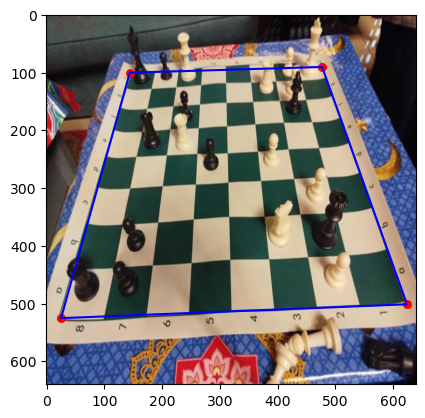

In [42]:
plt.imshow(img.permute(1,2,0))
plt.plot(*zip(*(list(quad) + [quad[0]])), 'b-');
plt.scatter(*zip(*quad), c='r', s=30);
quad

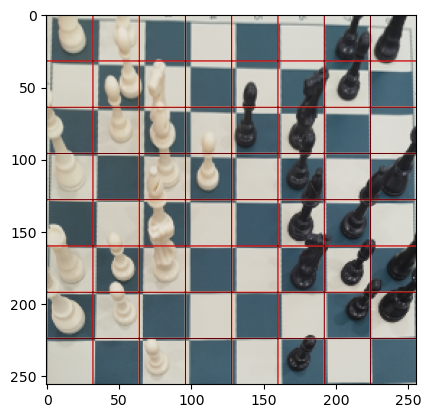

In [25]:
warpped, M = BE.warp(quad)

grid = np.zeros((256,256))
step = 32
# Set pixels in rows and columns that are multiples of step to 1
grid[::step, :] = 1   # horizontal lines
grid[:, ::step] = 1   # vertical lines

plt.imshow(warpped);
plt.imshow(grid, alpha=grid, cmap='Reds');